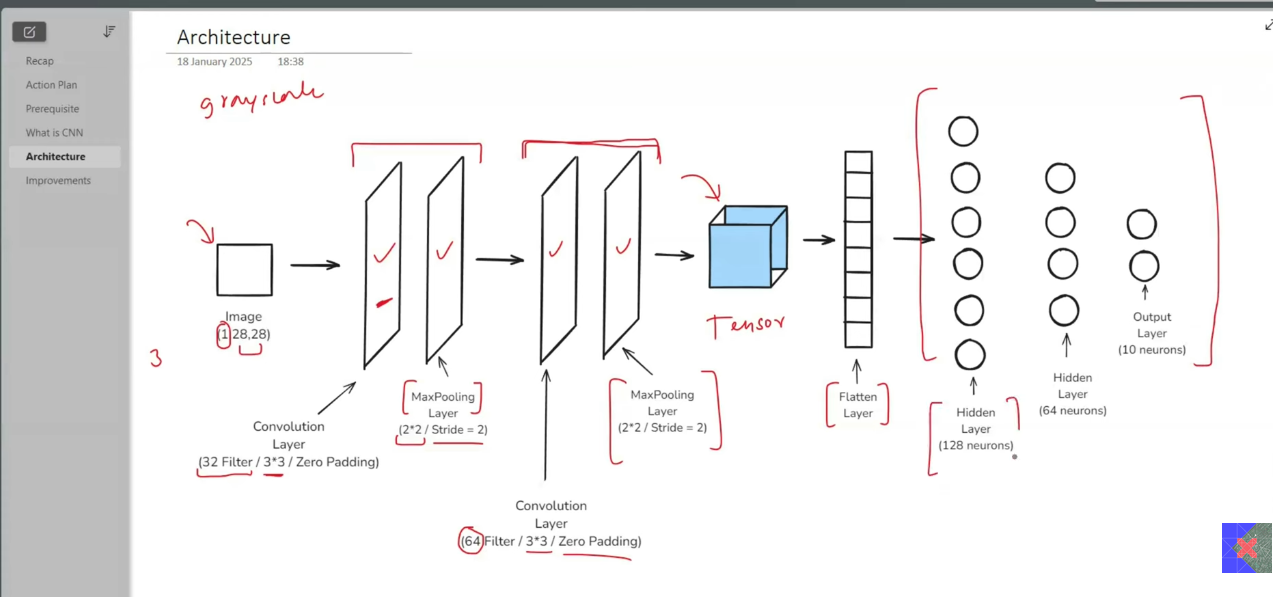

In [9]:
import torch 
import torch.functional as F
import torch.nn as nn 
import torch.optim as optim 
from torch.utils.data import Dataset, DataLoader


from sklearn.model_selection import train_test_split

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline 

import optuna 

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [83]:
dataset = pd.DataFrame(pd.read_csv(r'../datasets/fmnist_small.csv'))
dataset.drop('label', axis=1).shape

X = dataset.drop('label', axis=1)
y = dataset['label']

X_train, X_test, y_train, y_test = train_test_split(np.array(X), np.array(y), test_size=0.2,random_state=42)

X_train = X_train/255
X_test = X_test/255

len(X_train)

4800

In [84]:
class imageDataset(Dataset) : 

    def __init__(self, features, labels) :
        self.features = torch.tensor(features, dtype= torch.float32).reshape(-1, 1,28,28)
        self.labels = torch.tensor(labels, dtype= torch.long)


    def __len__(self) :
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]

In [85]:
train_Dataset = imageDataset(X_train, y_train)
test_Dataset = imageDataset(X_test, y_test)


train_dataLoader = DataLoader(train_Dataset, pin_memory_device=True, shuffle = True, batch_size=32)
test_dataLoader = DataLoader(test_Dataset, pin_memory_device=True, shuffle = False, batch_size=32)

In [86]:
len(train_dataLoader)

150

In [98]:
class CnnMODEL(nn.Module) :

    def __init__(self,input_features_count):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Conv2d(input_features_count, 32, kernel_size=3,padding="same"),
            nn.ReLU(),   
            nn.BatchNorm2d(32),
            nn.MaxPool2d(kernel_size=2, stride = 2),

            nn.Conv2d(32, 64, kernel_size=3, padding="same"),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128),
            nn.ReLU(),
            nn.Dropout(p=0.4),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(p=0.4),

            nn.Linear(64, 10)
        )


    def forward(self, input):

        return self.classifier(self.feature_extractor(input))

model_CNN = CnnMODEL(1)
model_CNN.to(device)
model_CNN.train()
        

CnnMODEL(
  (feature_extractor): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): ReLU()
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.4, inplace=False)
    (7): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [88]:
lr = 0.1
epochs  = 100

loss_func = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_CNN.parameters(), lr=lr, weight_decay=1e-4)

In [90]:


for epoch in range(epochs) : 
    epoch_loss = 0

    for batch_feature, batch_label in train_dataLoader :

        batch_feature, batch_label = batch_feature.to(device), batch_label.to(device)
        # print(batch_feature.shape)
        # print(batch_label.shape)
        
        batch_preds = model_CNN(batch_feature)
       

        #loss
        loss = loss_func(batch_preds, batch_label)
        

        #optimzer 
        optimizer.zero_grad()
        loss.backward()

        epoch_loss += loss.item()


        #Step
        optimizer.step()
    print(f'LOSS IN EPOCH {epoch} : {epoch_loss/len(train_dataLoader)}')


LOSS IN EPOCH 0 : 0.02095480835422677
LOSS IN EPOCH 1 : 0.024499458439343393
LOSS IN EPOCH 2 : 0.030261593090608586
LOSS IN EPOCH 3 : 0.024880888701754884
LOSS IN EPOCH 4 : 0.0356952514367246
LOSS IN EPOCH 5 : 0.04068730922192723
LOSS IN EPOCH 6 : 0.04750854557438288
LOSS IN EPOCH 7 : 0.030739200687833847
LOSS IN EPOCH 8 : 0.024768761734582465
LOSS IN EPOCH 9 : 0.025445704900412237
LOSS IN EPOCH 10 : 0.026906316504009736
LOSS IN EPOCH 11 : 0.04024106299443398
LOSS IN EPOCH 12 : 0.02520878717466985
LOSS IN EPOCH 13 : 0.027937732338599138
LOSS IN EPOCH 14 : 0.025394053356255122
LOSS IN EPOCH 15 : 0.04643449209400084
LOSS IN EPOCH 16 : 0.030927315146279093
LOSS IN EPOCH 17 : 0.037947993895359106
LOSS IN EPOCH 18 : 0.03508609174239003
LOSS IN EPOCH 19 : 0.03749586084801801
LOSS IN EPOCH 20 : 0.024440645122922433
LOSS IN EPOCH 21 : 0.030289593291272468
LOSS IN EPOCH 22 : 0.030076380565442377
LOSS IN EPOCH 23 : 0.02590044450046359
LOSS IN EPOCH 24 : 0.02499615426279585
LOSS IN EPOCH 25 : 0.0

In [96]:
model_CNN.eval()

total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in train_dataLoader :
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        feature_preds = model_CNN(batch_features)

        _, output_lables = torch.max(feature_preds, 1)

        total = total + batch_labels.shape[0]
        correct = correct + (output_lables == batch_labels).sum().item()
    print(correct/total)
                                           

1.0


In [97]:
model_CNN.eval()

total = 0
correct = 0

with torch.no_grad():

    for batch_features, batch_labels in test_dataLoader :
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        feature_preds = model_CNN(batch_features)

        _, output_lables = torch.max(feature_preds, 1)

        total = total + batch_labels.shape[0]
        correct = correct + (output_lables == batch_labels).sum().item()
    print(correct/total)
                                           

0.8641666666666666
